### Loading Data into Pandas DataFrame

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("marketing_campaign_performance_10000.csv")

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  object 
 1   StartDate    10000 non-null  object 
 2   EndDate      10000 non-null  object 
 3   Channel      10000 non-null  object 
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB


### Date Column Conversion

In [38]:
for col in ['StartDate','EndDate']:
  df[col] = pd.to_datetime(df[col])

In [39]:
display(df.dtypes)

,0
CampaignID,object
StartDate,datetime64[ns]
EndDate,datetime64[ns]
Channel,object
Impressions,int64
Clicks,int64
Leads,int64
Conversions,int64
Cost_USD,float64
Revenue_USD,float64


### Renaming Columns for Clarity

In [40]:
df = df.rename(columns = {'CampaignID':'Campaign_id','StartDate':'Start_date','EndDate':'End_date','Cicks':'Clicks_count'})

In [41]:
df.head(5)

,Campaign_id,Start_date,End_date,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86


In [42]:
df.isnull().sum()

,0
Campaign_id,0
Start_date,0
End_date,0
Channel,0
Impressions,0
Clicks,0
Leads,0
Conversions,0
Cost_USD,0
Revenue_USD,0


### Calculating Customer Acquisition Cost (CAC)

In [43]:
df['CAC'] = round(df['Cost_USD']/df['Conversions'],2)

### Calculating Return On Ad Spend (ROAS)

In [44]:
df['ROAS'] = round(df['Revenue_USD']/df['Cost_USD'],2)
print(df['ROAS'])

0       2.12
1       2.96
2       1.90
3       1.76
4       2.86
        ... 
9995    2.76
9996    1.59
9997    2.90
9998    2.28
9999    1.39
Name: ROAS, Length: 10000, dtype: float64


### Calculating Click-Through Rate (CTR)

In [45]:
df['CTR'] = (df['Clicks']/df['Impressions'])*100
df['CTR'].round(2)

,CTR
0,7.95
1,7.91
2,6.88
3,1.71
4,1.46
...,...
9995,1.69
9996,6.50
9997,9.78
9998,7.55


###Conversion Rate

In [46]:
df['Conversion_rate'] = (df['Conversions']/df['Clicks'] )*100
df['Conversion_rate'].round(2)

,Conversion_rate
0,23.09
1,15.77
2,20.62
3,12.80
4,13.60
...,...
9995,8.02
9996,8.28
9997,11.47
9998,3.60


### Average Marketing Metrics by Channel

In [47]:
channel_avg = df.groupby('Channel')[['ROI','ROAS','Conversion_rate', 'CAC', 'Cost_USD', 'Revenue_USD']].mean()

print("AVERAGE METRICS BY CHANNEL","\n")
print(channel_avg.round(2))

AVERAGE METRICS BY CHANNEL 

             ROI  ROAS  Conversion_rate    CAC  Cost_USD  Revenue_USD
Channel                                                              
Display     1.00  2.00            12.11  10.80   2582.50      5178.89
Email       1.01  2.01            12.12  10.13   2537.59      5075.42
Influencer  1.00  2.00            11.99   9.11   2567.50      5135.27
Search      1.01  2.01            12.11  10.89   2555.39      5144.32
Social      0.99  1.99            12.14  10.33   2516.62      4974.44


### Analyzing Channel Performance

In [48]:
channel_avg_sort = channel_avg.sort_values(by='ROAS',ascending=False)
print("CHANNELS RANKED BY ROAS (Best to Worst)")
print(channel_avg_sort.round(2))

CHANNELS RANKED BY ROAS (Best to Worst)
             ROI  ROAS  Conversion_rate    CAC  Cost_USD  Revenue_USD
Channel                                                              
Search      1.01  2.01            12.11  10.89   2555.39      5144.32
Email       1.01  2.01            12.12  10.13   2537.59      5075.42
Display     1.00  2.00            12.11  10.80   2582.50      5178.89
Influencer  1.00  2.00            11.99   9.11   2567.50      5135.27
Social      0.99  1.99            12.14  10.33   2516.62      4974.44


### Top 10 Campaigns by ROAS

In [49]:
top_10 = df.nlargest(10,'ROAS')[['Campaign_id','Channel','Cost_USD','Revenue_USD','ROAS','ROI','CAC']]
print(top_10)

     Campaign_id     Channel  Cost_USD  Revenue_USD  ROAS  ROI    CAC
142    CAMP00143      Search   3743.41     11217.85   3.0  2.0  85.08
202    CAMP00203      Search    415.48      1245.51   3.0  2.0   0.53
426    CAMP00427  Influencer   4362.61     13071.47   3.0  2.0  23.45
581    CAMP00582       Email   3614.24     10830.77   3.0  2.0   7.53
722    CAMP00723     Display   4324.84     12957.52   3.0  2.0  14.00
903    CAMP00904     Display   2284.84      6848.00   3.0  2.0   0.69
1392   CAMP01393     Display   3381.99     10145.25   3.0  2.0   5.50
1573   CAMP01574     Display   1167.03      3496.29   3.0  2.0   3.46
2749   CAMP02750      Search    101.02       302.73   3.0  2.0   0.21
3000   CAMP03001      Search   1655.51      4963.65   3.0  2.0   7.77


### Bottom 10 Campaigns by ROAS

In [50]:
# Bottom 10 campaigns by ROAS
bottom_10 = df.nsmallest(10,'ROAS')[['Campaign_id','Channel','Cost_USD','Revenue_USD','ROAS','ROI','CAC']]
print(bottom_10)

     Campaign_id     Channel  Cost_USD  Revenue_USD  ROAS  ROI   CAC
112    CAMP00113  Influencer    498.28       498.97   1.0  0.0  0.51
452    CAMP00453       Email   2199.91      2207.45   1.0  0.0  2.02
476    CAMP00477      Social   3686.54      3698.54   1.0  0.0  5.57
673    CAMP00674     Display   3069.42      3074.40   1.0  0.0  4.40
745    CAMP00746  Influencer    463.63       465.08   1.0  0.0  0.69
1080   CAMP01081  Influencer   4232.74      4247.54   1.0  0.0  3.41
2291   CAMP02292      Search    632.58       634.00   1.0  0.0  8.43
2975   CAMP02976  Influencer   1721.21      1728.22   1.0  0.0  4.23
3321   CAMP03322      Search    981.40       984.97   1.0  0.0  0.62
3935   CAMP03936  Influencer   4496.34      4509.52   1.0  0.0  7.38


### Overall Marketing Performance Summary Statistics

In [51]:

total_spend = df['Cost_USD'].sum()
total_revenue = df['Revenue_USD'].sum()
total_profit = total_revenue - total_spend

print(f"\nFINANCIAL SUMMARY:")
print(f"Total Spend: ${total_spend:,.2f}")
print(f'Total Revenue: ${total_revenue:,.2f}')
print(f'Total Profit: ${total_profit:,.2f}')
print(f'Profit Margin:${(total_profit/total_revenue)*100:.2f}')


FINANCIAL SUMMARY:
Total Spend: $25,523,569.91
Total Revenue: $51,026,489.30
Total Profit: $25,502,919.39
Profit Margin:$49.98


In [52]:
print(f"\nPERFORMANCE METRICS:")
print(f"  Average ROAS:          {df['ROAS'].mean():.2f}:1")
print(f"  Average ROI:           {df['ROI'].mean():.2f}%")
print(f"  Average CAC:           ${df['CAC'].mean():.2f}")
print(f"  Average Conversion Rate: {df['Conversion_rate'].mean():.2f}%")
print(f"  Average CTR:           {df['CTR'].mean():.2f}%")


PERFORMANCE METRICS:
  Average ROAS:          2.00:1
  Average ROI:           1.00%
  Average CAC:           $10.25
  Average Conversion Rate: 12.09%
  Average CTR:           5.46%


### Segmenting Campaigns by Performance Tiers

In [53]:

q1 = df['ROAS'].quantile(0.25)
q2 = df['ROAS'].quantile(0.50)
q3 = df['ROAS'].quantile(0.75)

high_roas = df[df['ROAS'] > q3]
medium_high_roas = df[(df['ROAS']>q2)& (df['ROAS']<=q3)]
medium_low_roas = df[(df['ROAS']>q1)& (df['ROAS']<=q2)]
low_roas = df[df['ROAS']<=q1]

segments = [
    ('High performers (top 25%)', high_roas),
    ('medium-high performers (50-75%)',medium_high_roas),
    ('medium-low performers (25-50%)',medium_low_roas),
    ('low_performers (bottom 25%)',low_roas)
]

for name, segment in segments:
    print(f"\n{name}:")
    print(f'ROAS Range: {segment['ROAS'].min():.2f}:1 - {segment["ROAS"].max():.2f}:1')
    print(f'No.of Campaigns: {len(segment)}')
    print(f'TOtal Spend: ${segment['Cost_USD'].sum():.2f}')
    print(f'Total Revenue: ${segment["Revenue_USD"].sum():.2f}')
    print(f'Average ROAS: ${segment['ROAS'].mean():.2f}:1')
    print(f'Average ROI: {segment["ROI"].mean():.2f}')
    print(f'Average CAC: {segment['CAC'].mean():.2f}')


High performers (top 25%):
ROAS Range: 2.52:1 - 3.00:1
No.of Campaigns: 2455
TOtal Spend: $6219316.42
Total Revenue: $17155247.17
Average ROAS: $2.76:1
Average ROI: 1.76
Average CAC: 9.96

medium-high performers (50-75%):
ROAS Range: 2.00:1 - 2.51:1
No.of Campaigns: 2532
TOtal Spend: $6444056.16
Total Revenue: $14557118.08
Average ROAS: $2.26:1
Average ROI: 1.26
Average CAC: 9.25

medium-low performers (25-50%):
ROAS Range: 1.51:1 - 1.99:1
No.of Campaigns: 2485
TOtal Spend: $6383435.90
Total Revenue: $11181850.63
Average ROAS: $1.75:1
Average ROI: 0.75
Average CAC: 11.01

low_performers (bottom 25%):
ROAS Range: 1.00:1 - 1.50:1
No.of Campaigns: 2528
TOtal Spend: $6476761.43
Total Revenue: $8132273.42
Average ROAS: $1.25:1
Average ROI: 0.25
Average CAC: 10.77


### Comprehensive Channel Performance Metrics

In [54]:
channel_performance = df.groupby('Channel').agg({
    'Cost_USD':'sum',
    'Revenue_USD':'sum',
    'ROAS':'mean',
    'ROI':'mean',
    'CAC':'mean',
    'Conversion_rate':'mean',
    'Campaign_id':'count'
}).round(2)

channel_performance.columns = ['Total Spend','Total Revenue','Average ROAS','Average ROI','Average CAC','Average Conversion Rate','Total Campaigns']
channel_performance['Total Profit'] = channel_performance['Total Revenue'] - channel_performance['Total Spend']

print(channel_performance)


            Total Spend  Total Revenue  Average ROAS  Average ROI  \
Channel                                                             
Display      5343184.30    10715125.21          2.00         1.00   
Email        5065029.98    10130542.61          2.01         1.01   
Influencer   5278787.92    10558118.99          2.00         1.00   
Search       4916568.46     9897677.79          2.01         1.01   
Social       4919999.25     9725024.70          1.99         0.99   

            Average CAC  Average Conversion Rate  Total Campaigns  \
Channel                                                             
Display           10.80                    12.11             2069   
Email             10.13                    12.12             1996   
Influencer         9.11                    11.99             2056   
Search            10.89                    12.11             1924   
Social            10.33                    12.14             1955   

            Total Profit  
Chann

### Channel Performance Sorted by Average ROAS

In [55]:

channel_performance = channel_performance.sort_values('Average ROAS',ascending=False)

print(channel_performance.to_string())



            Total Spend  Total Revenue  Average ROAS  Average ROI  Average CAC  Average Conversion Rate  Total Campaigns  Total Profit
Channel                                                                                                                               
Email        5065029.98    10130542.61          2.01         1.01        10.13                    12.12             1996    5065512.63
Search       4916568.46     9897677.79          2.01         1.01        10.89                    12.11             1924    4981109.33
Display      5343184.30    10715125.21          2.00         1.00        10.80                    12.11             2069    5371940.91
Influencer   5278787.92    10558118.99          2.00         1.00         9.11                    11.99             2056    5279331.07
Social       4919999.25     9725024.70          1.99         0.99        10.33                    12.14             1955    4805025.45


### Identifying Best and Worst Performing Channels

In [56]:


print('Best Channel(Heighest Return On Ads Spend)')
best_channel = channel_performance.index[0]
print(f'{best_channel}: ${channel_performance.loc[best_channel, 'Average ROAS']:.2f}:1')

print('\nWorst Channel(Lowest Return On Ads Spend)')
worst_channel = channel_performance.index[-1]
print(f'{worst_channel}: ${channel_performance.loc[worst_channel,'Average ROAS']:.2f}:1')

Best Channel(Heighest Return On Ads Spend)
Email: $2.01:1

Worst Channel(Lowest Return On Ads Spend)
Social: $1.99:1


### Visualization Part: Average ROAS by Channel

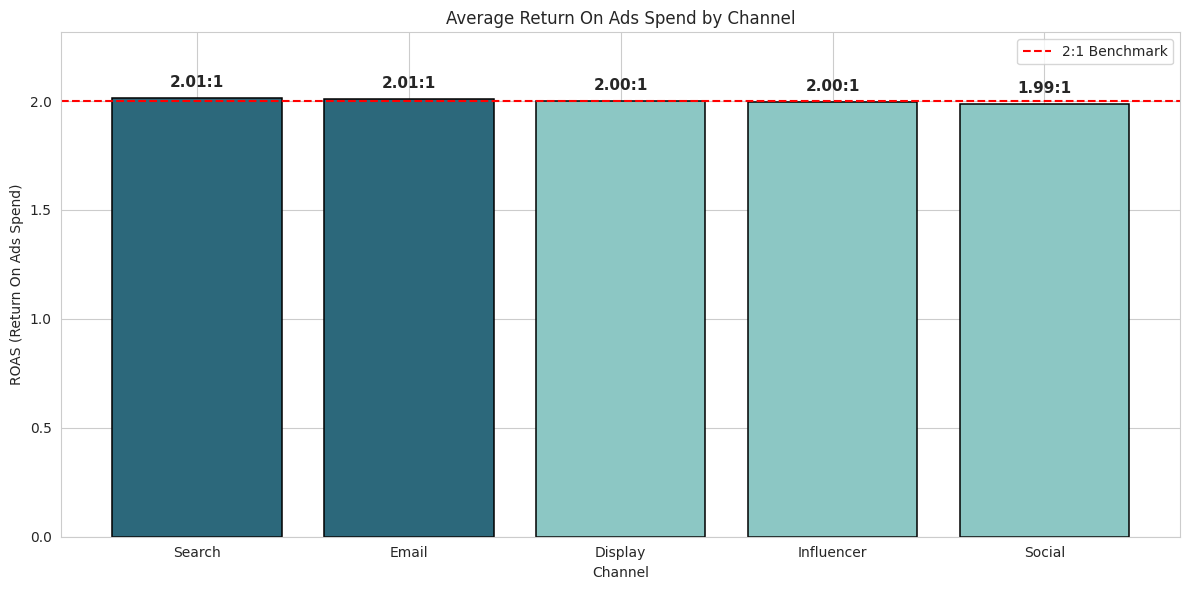

<Figure size 640x480 with 0 Axes>

In [57]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.figure(figsize=(12,6))

roas_by_channel = df.groupby('Channel')['ROAS'].mean().sort_values(ascending =False)
colors= ['#2C687B' if x > 2 else '#8CC7C4' for x in roas_by_channel.values]
plt.bar(roas_by_channel.index,roas_by_channel.values,color = colors,edgecolor='black',linewidth =1.1)
plt.axhline(y=2,color='red',linestyle='--',label='2:1 Benchmark')

plt.xlabel('Channel')
plt.ylabel('ROAS (Return On Ads Spend)')
plt.title('Average Return On Ads Spend by Channel')

for i ,v in enumerate(roas_by_channel.values):
  plt.text(i,v+0.05,f'{v:.2f}:1',ha='center',fontweight='bold',fontsize=11)
plt.ylim(0,max(roas_by_channel.values)*1.15)
plt.tight_layout()
plt.legend()
plt.show()
plt.savefig('roas_by_channel.png')

### Visualization Part: Average CAC by Channel

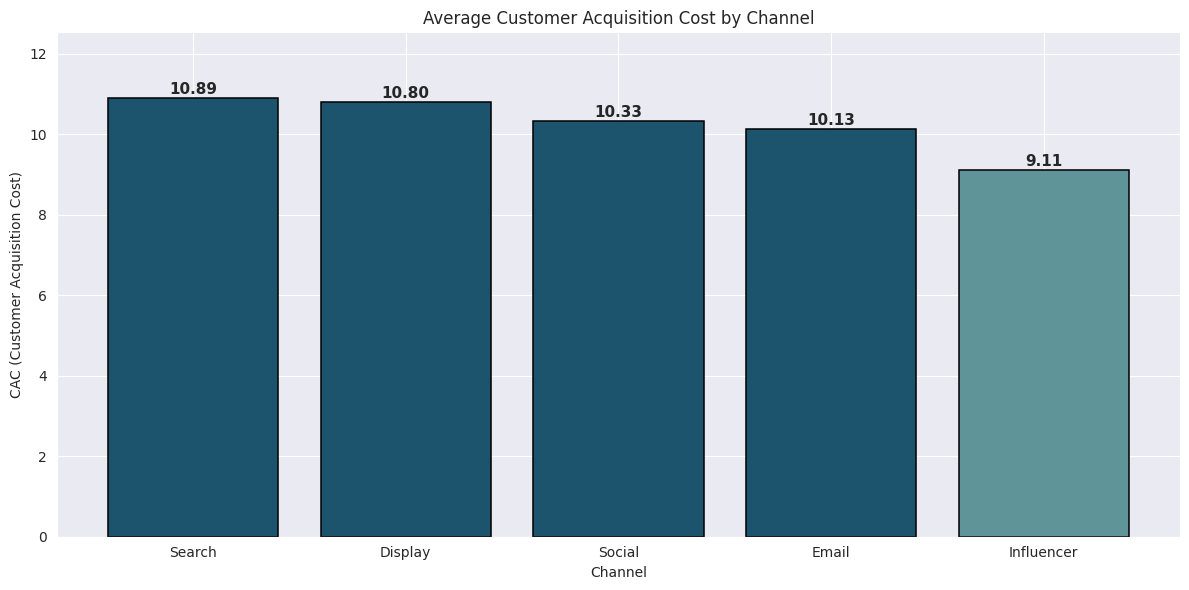

<Figure size 640x480 with 0 Axes>

In [58]:
sns.set_style('darkgrid')
plt.figure(figsize=(12,6))

cac_by_channel = df.groupby('Channel')['CAC'].mean().sort_values(ascending=False)
colors = ['#1D546D'if x > 10.00 else '#5F9598' for x in cac_by_channel.values]

plt.bar(cac_by_channel.index, cac_by_channel.values, color= colors, edgecolor='black', linewidth=1.1)

plt.xlabel('Channel')
plt.ylabel('CAC (Customer Acquisition Cost)')
plt.title('Average Customer Acquisition Cost by Channel')

# Adding value labels on top of each bar for better readability
for i, v in enumerate(cac_by_channel.values):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, cac_by_channel.max() * 1.15) # Adjust y-limit to make space for labels
plt.tight_layout()
plt.show()
plt.savefig('cac_by_channel.png')

### Visualization Part: Total Revenue by Channel

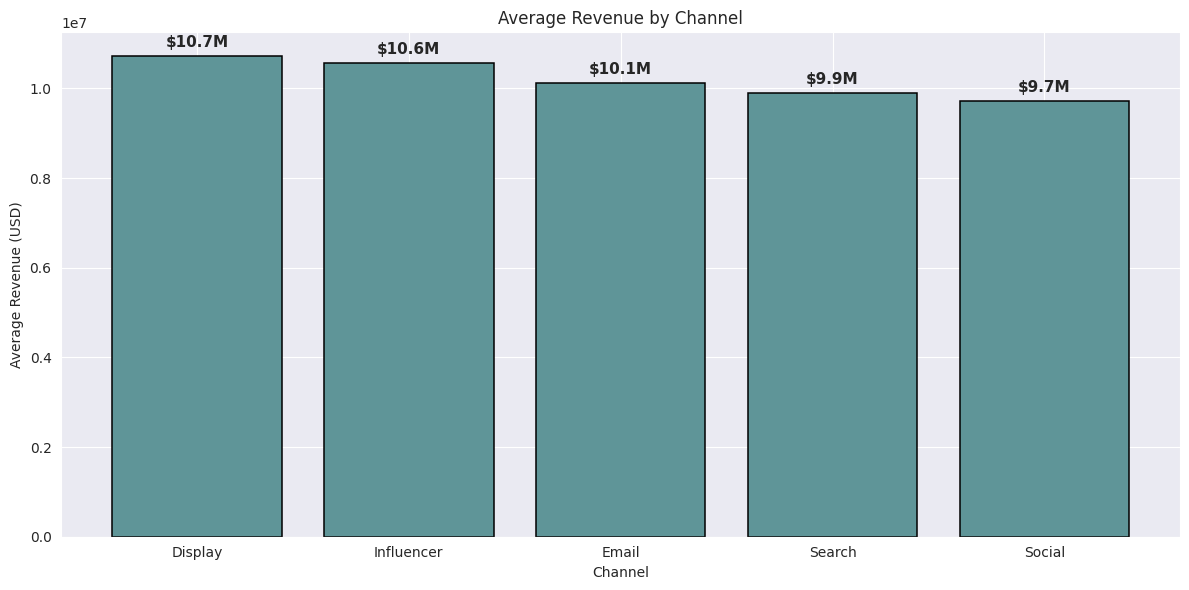

<Figure size 640x480 with 0 Axes>

In [59]:

plt.figure(figsize=(12,6))

revenue_by_channel = df.groupby('Channel')['Revenue_USD'].sum().sort_values(ascending=False)
plt.bar(revenue_by_channel.index, revenue_by_channel.values,color='#5F9598' , edgecolor='black', linewidth=1.1)
plt.xlabel('Channel')
plt.ylabel('Average Revenue (USD)')
plt.title('Average Revenue by Channel')
for i, (channel, value) in enumerate(revenue_by_channel.items()):
    plt.text(i, value + 200000, f'${value/1e6:.1f}M', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()
plt.savefig('revenue_by_channel.png')

### Visualization Part: Campaign Count by Channel

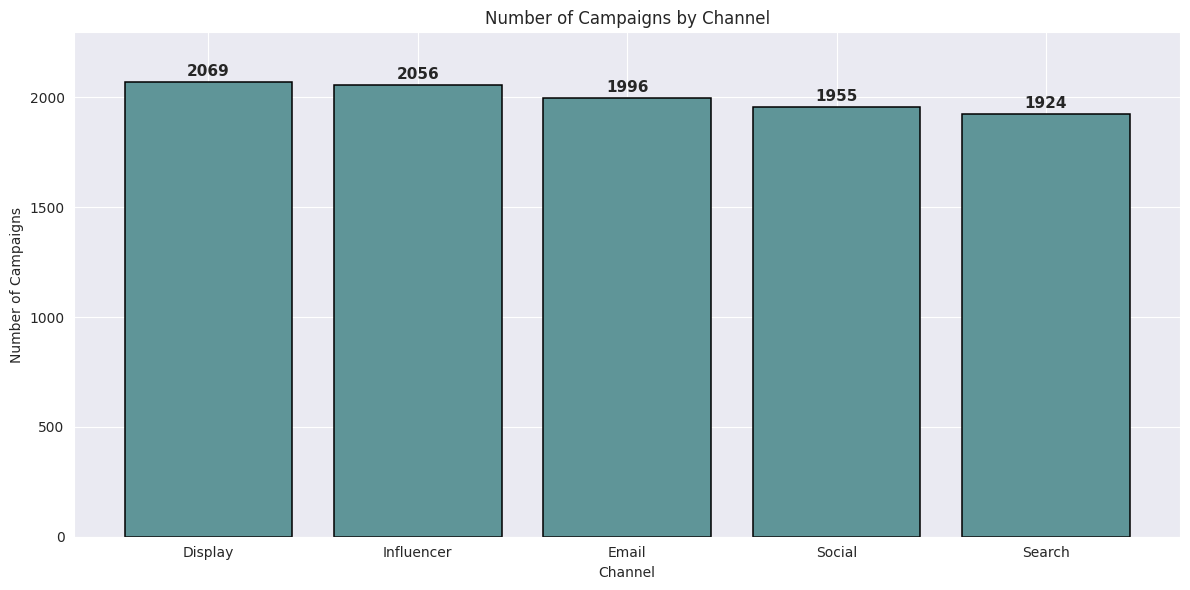

<Figure size 640x480 with 0 Axes>

In [60]:
## 📊 CODE BLOCK 10: CHART 4 - CAMPAIGN COUNT BY CHANNEL

plt.figure(figsize=(12,6))

campaign_count = df['Channel'].value_counts().sort_values(ascending=False)
plt.bar(campaign_count.index,campaign_count.values,color='#5F9598',edgecolor='black',linewidth=1.1)
plt.xlabel('Channel')
plt.ylabel('Number of Campaigns')
plt.title('Number of Campaigns by Channel')

for i,v in enumerate(campaign_count.values):
  plt.text(i,v+30,v,ha='center',fontweight='bold',fontsize=11)

plt.ylim(0,max(campaign_count)*1.11)
plt.tight_layout()
plt.show()
plt.savefig('campaign_count_by_channel.png')